In [55]:
import numpy as np
import matplotlib.pyplot as plt
from cymr.network import Network

# Utility function to print vectors cleanly
def print_vec(name, vec):
    print(f"{name}: {np.round(vec, 2)}")


## 1. Network Initialization

In [56]:
n_items = 20 # 15 study items + 5 distractors
net = Network({'loc': {'item': n_items}}, {'loc': {'item': n_items}})
net.add_pre_weights('fc', ('loc', 'item'), ('loc', 'item'), np.eye(n_items))

B_enc = 0.5   # Context drift rate during encoding (0.5 yields exact peak of 0.8)
Lfc = 1.0     
c_study = []

## 2. Study Phase and Distractor Phase

In [57]:
# Events 0-14: Study Phase
# Events 15-19: Distractor Phase
print("=== STUDY & DISTRACTOR PHASE ===")
for i in range(n_items):
    print(f"\n--- Step {i} (Item {i}) ---")
    
    # Before presentation, let's see what context it retrieves
    # We combine both the pre-experimental identity and the learned experimental context
    c_in = net.w_fc_pre[i, :] + net.w_fc_exp[i, :]
    print_vec("Retrieved Context (w_fc_pre + w_fc_exp)", c_in)
    
    # net.present automatically integrates the context using a leaky integrator
    net.present(('loc', 'item', i), 'loc', B_enc, Lfc, 0.0)
    
    # The new network context
    print_vec("Network Context (net.c)", net.c)
    
    
    c_study.append(net.c.copy())
    
c_study_arr = np.array(c_study)

=== STUDY & DISTRACTOR PHASE ===

--- Step 0 (Item 0) ---
Retrieved Context (w_fc_pre + w_fc_exp): [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Network Context (net.c): [0.5 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
 0.  0. ]

--- Step 1 (Item 1) ---
Retrieved Context (w_fc_pre + w_fc_exp): [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Network Context (net.c): [0.43 0.5  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.  ]

--- Step 2 (Item 2) ---
Retrieved Context (w_fc_pre + w_fc_exp): [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Network Context (net.c): [0.37 0.43 0.5  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.  ]

--- Step 3 (Item 3) ---
Retrieved Context (w_fc_pre + w_fc_exp): [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Network Context (net.c): [0.32 0.37 0.43 0.5  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0

## 3. Recall Phase

In [58]:

B_rec = 0.5

c_recall = []
recall_sequence = [14, 9, 0, 1, 3, 2] # Items 15, 10, 1, 2, 4, 3

print("\n=== RECALL PHASE ===")
for idx, i in enumerate(recall_sequence):
    print(f"\n--- Recall Step {idx} (Recalling Item {i}) ---")
    # The recalled item retrieves its pre-experimental context
    c_in = net.w_fc_exp[i, :]
    print_vec("Retrieved Context (w_fc_exp[i])", c_in)
    
    # We continuously integrate the retrieved context
    net.c = np.sqrt(1 - B_rec**2) * net.c + B_rec * c_in
    print_vec("Network Context (net.c)", net.c)
    
    # What items does this new context cue?
    cued_items = np.dot(net.c, net.w_cf_exp)
    print_vec("Cued Items (net.c @ w_cf_exp)", cued_items)
    
    c_recall.append(net.c.copy())
    
c_recall_arr = np.array(c_recall)


=== RECALL PHASE ===

--- Recall Step 0 (Recalling Item 14) ---
Retrieved Context (w_fc_exp[i]): [0.07 0.08 0.09 0.1  0.12 0.14 0.16 0.18 0.21 0.24 0.28 0.32 0.37 0.43
 0.5  0.   0.   0.   0.   0.  ]
Network Context (net.c): [0.06 0.07 0.08 0.09 0.11 0.13 0.15 0.17 0.19 0.22 0.26 0.3  0.35 0.4
 0.46 0.24 0.28 0.32 0.37 0.43]
Cued Items (net.c @ w_cf_exp): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

--- Recall Step 1 (Recalling Item 9) ---
Retrieved Context (w_fc_exp[i]): [0.14 0.16 0.18 0.21 0.24 0.28 0.32 0.37 0.43 0.5  0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.  ]
Network Context (net.c): [0.12 0.14 0.16 0.19 0.22 0.25 0.29 0.33 0.38 0.44 0.22 0.26 0.3  0.35
 0.4  0.21 0.24 0.28 0.32 0.37]
Cued Items (net.c @ w_cf_exp): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

--- Recall Step 2 (Recalling Item 0) ---
Retrieved Context (w_fc_exp[i]): [0.5 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
 0.  0. ]
Network Context (net.c): 

## 4. Context Reinstatement Lag Plot (Plot F)

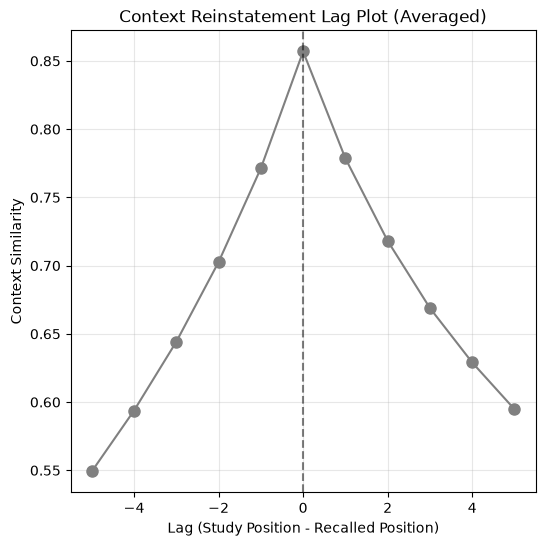

In [59]:
lags = np.arange(-5, 6)
lag_similarities = {lag: [] for lag in lags}

np.random.seed(42)

for _ in range(500):
    temp_c = np.zeros(n_items)
    rand_seq = np.random.choice(15, size=5, replace=False)
    
    c_rec_temp = []
    for i in rand_seq:
        c_in = net.w_fc_exp[i, :]
        temp_c = np.sqrt(1 - B_rec**2) * temp_c + B_rec * c_in
        c_rec_temp.append(temp_c.copy())
        
    for idx, recalled_item in enumerate(rand_seq):
        c_rec = c_rec_temp[idx]
        for study_pos in range(15):
            lag = study_pos - recalled_item
            if lag in lags:
                sim = np.dot(c_rec, c_study_arr[study_pos]) / (np.linalg.norm(c_rec) * np.linalg.norm(c_study_arr[study_pos]))
                lag_similarities[lag].append(sim)

mean_similarities = [np.mean(lag_similarities[l]) for l in lags]

plt.figure(figsize=(6, 6))
plt.plot(lags, mean_similarities, 'o-', color='gray', markersize=8)
plt.axvline(0, color='black', linestyle='--', alpha=0.5)
plt.xlabel('Lag (Study Position - Recalled Position)')
plt.ylabel('Context Similarity')
plt.title('Context Reinstatement Lag Plot (Averaged)')
plt.grid(True, alpha=0.3)
plt.show()

## 5. Feature Time Matrix (Plot C)

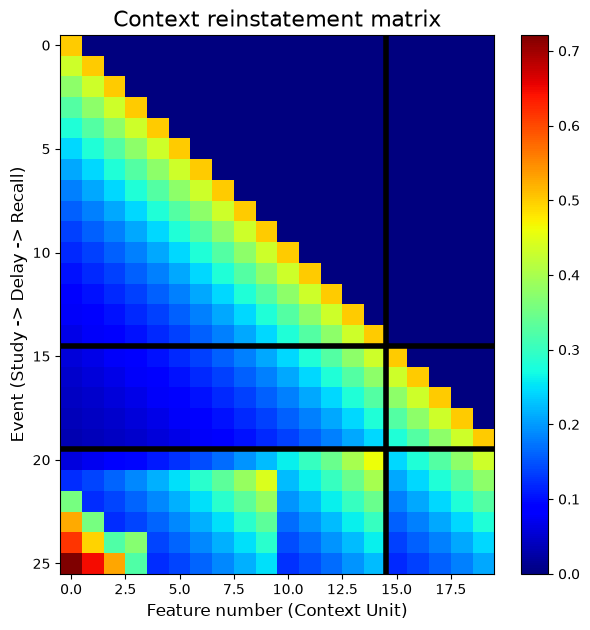

In [63]:
# Stack the study and single-trial recall context vectors vertically
c_combined = np.vstack([c_study_arr, c_recall_arr])

plt.figure(figsize=(7, 7))

# Plot using the 'jet' colormap
im = plt.imshow(c_combined, aspect='auto', cmap='jet', vmin=0, vmax=np.max(c_combined))
plt.colorbar(im)

# Add thick black lines to separate study phase (0-14), distractor phase (15-19), and recall phase
plt.axhline(y=14.5, color='black', linewidth=4)
plt.axhline(y=19.5, color='black', linewidth=4)
plt.axvline(x=14.5, color='black', linewidth=4)

plt.xlabel('Feature number (Context Unit)', fontsize=12)
plt.ylabel('Event (Study -> Delay -> Recall)', fontsize=12)
plt.title('Context reinstatement matrix', fontsize=16)

plt.show()